# K-NN no Titanic — FATEC

Atividade da aula de 18-08-2026. Neste roteiro preparamos o `train.csv` original da competição Titanic no Kaggle e treinamos k-Nearest Neighbors (k-NN) para prever `Survived`.

## Como o k-NN decide

Cada passageiro é representado por um vetor de atributos, por exemplo idade, tarifa e sexo. Para classificar um novo vetor, o k-NN calcula sua distância (por padrão, Euclidiana) até os vetores de treino, encontra os **k** vizinhos mais próximos e usa a votação majoritária de `Survived`. Por depender diretamente das distâncias, o método exige números, ausência de valores ausentes e escalas comparáveis.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data' / 'train.csv').exists() and (PROJECT_ROOT.parent / 'data' / 'train.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    REQUIRED_COLUMNS, apply_min_max, fit_min_max, fit_preprocessor,
    transform_features, validate_titanic_dataset,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'train.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset obrigatório não encontrado em {DATA_PATH}. Coloque aqui o train.csv original do Titanic — Kaggle; nenhuma fonte alternativa é usada.'
    )

print(f'Raiz do projeto: {PROJECT_ROOT}')
print(f'Dataset: {DATA_PATH}')

Raiz do projeto: D:\knn-titanic-fatec
Dataset: D:\knn-titanic-fatec\data\train.csv


## Exploração inicial e validação do CSV

Antes de modelar, confirmamos as colunas esperadas e observamos dimensões, tipos, exemplos, estatísticas, valores nulos e categorias. Isso evita preparar acidentalmente outro arquivo parecido.

In [2]:
titanic = pd.read_csv(DATA_PATH)
validate_titanic_dataset(titanic)

print(f'Linhas: {titanic.shape[0]} | Colunas: {titanic.shape[1]}')
print('\nTipos das colunas:')
display(titanic.dtypes.to_frame('dtype'))
print('\nPrimeiras linhas:')
display(titanic.head())
print('\nEstatísticas básicas:')
display(titanic.describe(include='all').T)
print('\nValores nulos por coluna:')
display(titanic.isna().sum().to_frame('nulos'))
print('\nCategorias relevantes:')
for column in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f'{column}: {titanic[column].value_counts(dropna=False).to_dict()}')

assert REQUIRED_COLUMNS.issubset(titanic.columns)

Linhas: 891 | Colunas: 12

Tipos das colunas:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64



Primeiras linhas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Estatísticas básicas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292



Valores nulos por coluna:


,nulos
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Categorias relevantes:
Survived: {0: 549, 1: 342}
Pclass: {3: 491, 1: 216, 2: 184}
Sex: {'male': 577, 'female': 314}
Embarked: {'S': 644, 'C': 168, 'Q': 77, nan: 2}


## Seleção de atributos

`PassengerId` é apenas identificador; `Name`, `Ticket` e `Cabin` são strings sem uma distância matemática direta útil neste exercício. Eles não entrarão no modelo. `Survived` não é removido: é o alvo que queremos prever.

In [3]:
target = titanic['Survived'].copy()
raw_features = titanic.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
print('Colunas candidatas ao modelo:', raw_features.columns.tolist())
assert 'Survived' not in raw_features.columns

Colunas candidatas ao modelo: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## Separação treino/teste antes das transformações

`X` contém os atributos e `y` contém `Survived`. Reservamos o teste para a avaliação final e usamos `stratify=y` para preservar a proporção entre sobreviventes e não sobreviventes. A mediana, moda e parâmetros de escala são ajustados apenas no treino: usar também o teste seria *data leakage*.

In [4]:
train_raw, test_raw, y_train, y_test = train_test_split(
    titanic, target, test_size=0.20, random_state=42, stratify=target
)
print(f'Treino: {train_raw.shape[0]} linhas | Teste: {test_raw.shape[0]} linhas')
print('Proporção Survived (treino/teste):', round(y_train.mean(), 3), round(y_test.mean(), 3))

Treino: 712 linhas | Teste: 179 linhas
Proporção Survived (treino/teste): 0.383 0.385


## Valores ausentes, encoding e engenharia de atributos

O k-NN não aceita `NaN`. Preenchemos `Age` pela mediana do treino e `Embarked` pela moda do treino. `Sex` é convertido por Pandas em `male → 0` e `female → 1`. `Embarked` e `Pclass` recebem dummies com `pd.get_dummies`; embora Pclass use 1, 2 e 3, aqui são categorias, não uma distância contínua. Para `Embarked`, C é a base e Q/S são indicadores. Criamos também `FamilySize = SibSp + Parch + 1`, usando-a no modelo expandido no lugar de SibSp e Parch.

In [5]:
preprocessor = fit_preprocessor(train_raw)
train_prepared = transform_features(train_raw, preprocessor, use_family_size=True)
test_prepared = transform_features(test_raw, preprocessor, use_family_size=True)

print('Mediana de Age ajustada no treino:', preprocessor.age_median)
print('Moda de Embarked ajustada no treino:', preprocessor.embarked_mode)
display(train_prepared.head())
print('NaN no treino preparado:', int(train_prepared.isna().sum().sum()))
print('NaN no teste preparado:', int(test_prepared.isna().sum().sum()))
print('Tipos finais:', train_prepared.dtypes.to_dict())
assert train_prepared.isna().sum().sum() == 0
assert test_prepared.isna().sum().sum() == 0
assert all(pd.api.types.is_numeric_dtype(dtype) for dtype in train_prepared.dtypes)

Mediana de Age ajustada no treino: 28.5
Moda de Embarked ajustada no treino: S


,Sex,Age,Fare,FamilySize,Pclass_1,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
692,0.0,28.5,56.4958,1.0,0.0,0.0,1.0,0.0,1.0
481,0.0,28.5,0.0000,1.0,0.0,1.0,0.0,0.0,1.0
527,0.0,28.5,221.7792,1.0,1.0,0.0,0.0,0.0,1.0
855,1.0,18.0,9.3500,2.0,0.0,0.0,1.0,0.0,1.0
801,1.0,31.0,26.2500,3.0,0.0,1.0,0.0,0.0,1.0


NaN no treino preparado: 0
NaN no teste preparado: 0
Tipos finais: {'Sex': dtype('float64'), 'Age': dtype('float64'), 'Fare': dtype('float64'), 'FamilySize': dtype('float64'), 'Pclass_1': dtype('float64'), 'Pclass_2': dtype('float64'), 'Pclass_3': dtype('float64'), 'Embarked_Q': dtype('float64'), 'Embarked_S': dtype('float64')}


## Min-Max Scaling manual

A distância Euclidiana soma diferenças ao quadrado. `Pclass` tem escala curta (1–3), enquanto `Fare` pode ser muito maior; sem escala, Fare poderia dominar a distância. A fórmula manual exigida é `x_norm = (x - x_min) / (x_max - x_min)`. As dummies e `Sex` já são 0/1; normalizamos as contínuas `Age`, `Fare` e, no modelo C, `FamilySize`. Os mínimos/máximos são obtidos só no treino e reutilizados no teste.

In [6]:
display(train_raw[['Pclass', 'Fare']].describe().T)

# Exemplo explícito da fórmula manual em Pandas (ajustada somente no treino).
scaling_example = fit_min_max(train_prepared, ['Age', 'Fare', 'FamilySize'])
display(apply_min_max(train_prepared[['Age', 'Fare', 'FamilySize']], scaling_example).head())

,count,mean,std,min,25%,50%,75%,max
Pclass,712.0,2.308989,0.833563,1.0,2.0000,3.0000,3.0,3.0000
Fare,712.0,31.819826,48.059104,0.0,7.8958,14.4542,31.0,512.3292


,Age,Fare,FamilySize
692,0.352852,0.110272,0.0
481,0.352852,0.000000,0.0
527,0.352852,0.432884,0.0
855,0.220910,0.018250,0.1
801,0.384267,0.051237,0.2


## Escolha de k com validação cruzada

`k` é o número de vizinhos que votam. Com `k=1`, um ponto ruidoso pode decidir a classe; um k muito grande suaviza demais as fronteiras. Valores ímpares reduzem empates em classificação binária. Avaliamos 1, 3, 5, 7, 9, 11, 13 e 15 somente dentro do treino com validação cruzada estratificada. Em cada fold, mediana, moda, mínimo e máximo são reaprendidos no fold-treino e aplicados ao fold-validação. Assim, nem o teste final nem o fold de validação orientam o pré-processamento.

In [7]:
K_VALUES = [1, 3, 5, 7, 9, 11, 13, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def build_experiment(features, continuous_columns):
    """Prepara o treino externo e o teste final sem usar estatísticas do teste."""
    X_train = train_prepared.loc[:, features].copy()
    X_test = test_prepared.loc[:, features].copy()
    min_max = fit_min_max(X_train, continuous_columns)
    return apply_min_max(X_train, min_max), apply_min_max(X_test, min_max)

def cross_validation_scores(features, continuous_columns):
    """Reajusta todo o pré-processamento dentro de cada fold."""
    fold_scores = {k: [] for k in K_VALUES}
    for fold_train_positions, fold_validation_positions in cv.split(train_raw, y_train):
        fold_train_raw = train_raw.iloc[fold_train_positions]
        fold_validation_raw = train_raw.iloc[fold_validation_positions]
        fold_y_train = y_train.iloc[fold_train_positions]
        fold_y_validation = y_train.iloc[fold_validation_positions]

        fold_preprocessor = fit_preprocessor(fold_train_raw)
        fold_train_prepared = transform_features(fold_train_raw, fold_preprocessor, use_family_size=True)
        fold_validation_prepared = transform_features(fold_validation_raw, fold_preprocessor, use_family_size=True)
        fold_min_max = fit_min_max(fold_train_prepared[features], continuous_columns)
        fold_X_train = apply_min_max(fold_train_prepared[features], fold_min_max)
        fold_X_validation = apply_min_max(fold_validation_prepared[features], fold_min_max)

        for k in K_VALUES:
            fold_model = KNeighborsClassifier(n_neighbors=k).fit(fold_X_train, fold_y_train)
            fold_scores[k].append(fold_model.score(fold_X_validation, fold_y_validation))
    return {k: sum(scores) / len(scores) for k, scores in fold_scores.items()}

def evaluate_knn(name, features, continuous_columns):
    cv_scores = cross_validation_scores(features, continuous_columns)
    best_k = max(cv_scores, key=lambda k: (cv_scores[k], -k))
    X_train_exp, X_test_exp = build_experiment(features, continuous_columns)
    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_train_exp, y_train)
    prediction = model.predict(X_test_exp)
    return {
        'name': name, 'features': features, 'k': best_k, 'cv_scores': cv_scores,
        'accuracy': accuracy_score(y_test, prediction),
        'confusion_matrix': confusion_matrix(y_test, prediction),
        'report': classification_report(y_test, prediction, digits=3),
        'model': model, 'X_train': X_train_exp, 'X_test': X_test_exp,
        'prediction': prediction,
    }

## Experimentos A, B e C

A é o baseline com idade e tarifa. B acrescenta sexo. C é o modelo expandido com sexo, as dummies de classe/embarque e tamanho da família. As métricas abaixo são avaliações finais no conjunto de teste reservado.

In [8]:
pclass_dummies = [column for column in train_prepared.columns if column.startswith('Pclass_')]
embarked_dummies = [column for column in train_prepared.columns if column.startswith('Embarked_')]

experiments = {
    'A': evaluate_knn('Experimento A', ['Age', 'Fare'], ['Age', 'Fare']),
    'B': evaluate_knn('Experimento B', ['Age', 'Fare', 'Sex'], ['Age', 'Fare']),
    'C': evaluate_knn(
        'Experimento C',
        ['Age', 'Fare', 'Sex', 'FamilySize', *pclass_dummies, *embarked_dummies],
        ['Age', 'Fare', 'FamilySize'],
    ),
}

for label, result in experiments.items():
    print(f"{result['name']} | features={result['features']} | k={result['k']} | accuracy={result['accuracy']:.4f}")
    print('Matriz de confusão (linhas: real 0/1; colunas: previsto 0/1):')
    print(result['confusion_matrix'])
    print(result['report'])

Experimento A | features=['Age', 'Fare'] | k=15 | accuracy=0.6089
Matriz de confusão (linhas: real 0/1; colunas: previsto 0/1):
[[84 26]
 [44 25]]
              precision    recall  f1-score   support

           0      0.656     0.764     0.706       110
           1      0.490     0.362     0.417        69

    accuracy                          0.609       179
   macro avg      0.573     0.563     0.561       179
weighted avg      0.592     0.609     0.594       179

Experimento B | features=['Age', 'Fare', 'Sex'] | k=15 | accuracy=0.7654
Matriz de confusão (linhas: real 0/1; colunas: previsto 0/1):
[[91 19]
 [23 46]]
              precision    recall  f1-score   support

           0      0.798     0.827     0.812       110
           1      0.708     0.667     0.687        69

    accuracy                          0.765       179
   macro avg      0.753     0.747     0.750       179
weighted avg      0.763     0.765     0.764       179

Experimento C | features=['Age', 'Fare', 'Sex

## Gráficos e comparação

O primeiro gráfico mostra o desempenho médio da validação cruzada (somente treino) para cada k. O segundo compara a acurácia final dos três experimentos. A conclusão deve seguir os números executados, sem forçar a hipótese de que `Sex` melhora necessariamente o resultado.

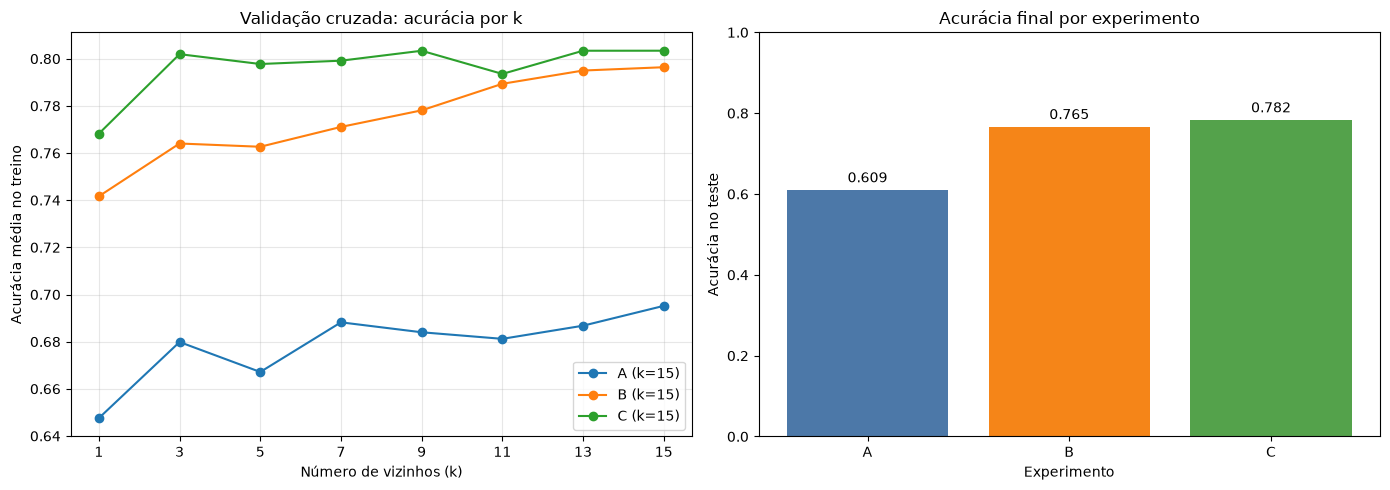

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, result in experiments.items():
    axes[0].plot(K_VALUES, [result['cv_scores'][k] for k in K_VALUES], marker='o', label=f"{label} (k={result['k']})")
axes[0].set_title('Validação cruzada: acurácia por k')
axes[0].set_xlabel('Número de vizinhos (k)')
axes[0].set_ylabel('Acurácia média no treino')
axes[0].set_xticks(K_VALUES)
axes[0].legend()
axes[0].grid(alpha=0.3)

labels = list(experiments)
accuracies = [experiments[label]['accuracy'] for label in labels]
bars = axes[1].bar(labels, accuracies, color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Acurácia final por experimento')
axes[1].set_xlabel('Experimento')
axes[1].set_ylabel('Acurácia no teste')
axes[1].set_ylim(0, 1)
for bar, value in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Verificação manual de uma previsão do k-NN

Agora reproduzimos uma previsão real do **Experimento C**, usando exatamente suas features e seu `k`. Para o passageiro escolhido do teste interno, a distância Euclidiana até cada passageiro do treino é:

```text
sqrt((x1 - y1)^2 + (x2 - y2)^2 + ... + (xn - yn)^2)
```

Ordenamos as distâncias, observamos os `k` vizinhos, somamos seus votos de `Survived` e comparamos a votação manual com `model.predict()`.

In [10]:
manual_result = experiments['C']
X_train_c = manual_result['X_train']
X_test_c = manual_result['X_test']
manual_index = X_test_c.index[0]
manual_query = X_test_c.loc[manual_index]

# Distância Euclidiana da consulta a todos os vetores de treino já preparados e escalados.
distances = ((X_train_c - manual_query) ** 2).sum(axis=1).pow(0.5).sort_values()
nearest_indices = distances.head(manual_result['k']).index
neighbors = pd.DataFrame({
    'PassengerId': train_raw.loc[nearest_indices, 'PassengerId'],
    'distância_euclidiana': distances.loc[nearest_indices],
    'Survived': y_train.loc[nearest_indices],
}).sort_values('distância_euclidiana')

query_display = X_test_c.loc[[manual_index]].copy()
query_display.insert(0, 'PassengerId', test_raw.loc[manual_index, 'PassengerId'])
display(query_display)
display(neighbors)

manual_prediction = int(neighbors['Survived'].sum() > manual_result['k'] / 2)
sklearn_prediction = int(manual_result['model'].predict(X_test_c.loc[[manual_index]])[0])
print(f"Índice interno: {manual_index} | PassengerId: {test_raw.loc[manual_index, 'PassengerId']}")
print(f"k: {manual_result['k']} | votos Survived=1: {int(neighbors['Survived'].sum())} | votos Survived=0: {int((neighbors['Survived'] == 0).sum())}")
print(f'Previsão manual: {manual_prediction}')
print(f'Previsão scikit-learn: {sklearn_prediction}')
assert manual_prediction == sklearn_prediction
print('Comparação manual do modelo C == model.predict(): PASS')

# Reproduz também a demonstração originalmente declarada para k=3.
legacy_k = 3
legacy_neighbors = neighbors.head(legacy_k)
legacy_manual_prediction = int(legacy_neighbors['Survived'].sum() > legacy_k / 2)
legacy_model_prediction = int(KNeighborsClassifier(n_neighbors=legacy_k).fit(X_train_c, y_train).predict(X_test_c.loc[[manual_index]])[0])
print(f"Checagem k=3 | vizinhos: {legacy_neighbors['PassengerId'].tolist()} | votos 0: {int((legacy_neighbors['Survived'] == 0).sum())} | votos 1: {int(legacy_neighbors['Survived'].sum())}")
print(f'Previsão manual k=3: {legacy_manual_prediction} | scikit-learn k=3: {legacy_model_prediction}')
assert legacy_neighbors['PassengerId'].tolist() == [70, 393, 425]
assert legacy_manual_prediction == legacy_model_prediction == 0
print('Reprodução da demonstração declarada com k=3: PASS')

,PassengerId,Age,Fare,Sex,FamilySize,Pclass_1,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
565,566,0.296306,0.047138,0.0,0.2,0.0,0.0,1.0,0.0,1.0


,PassengerId,distância_euclidiana,Survived
69,70,0.039312,0
392,393,0.059409,0
424,425,0.075787,0
175,176,0.081831,0
746,747,0.100816,0
93,94,0.103346,0
267,268,0.105733,1
704,705,0.107904,0
0,1,0.108258,0
403,404,0.113088,0


Índice interno: 565 | PassengerId: 566
k: 15 | votos Survived=1: 2 | votos Survived=0: 13
Previsão manual: 0
Previsão scikit-learn: 0
Comparação manual do modelo C == model.predict(): PASS
Checagem k=3 | vizinhos: [70, 393, 425] | votos 0: 3 | votos 1: 0
Previsão manual k=3: 0 | scikit-learn k=3: 0
Reprodução da demonstração declarada com k=3: PASS


## Resultado consolidado e verificações finais

A tabela registra atributos, k escolhido por validação, acurácia e diferença em relação ao baseline A. As verificações garantem que `Survived` não entrou em `X`, que não há NaN/string no k-NN e que a normalização foi ajustada no treino.

In [11]:
summary = pd.DataFrame([
    {
        'Experimento': label,
        'Features': ', '.join(result['features']),
        'k escolhido': result['k'],
        'Acurácia teste': result['accuracy'],
        'Diferença vs A': result['accuracy'] - experiments['A']['accuracy'],
    }
    for label, result in experiments.items()
])
display(summary)

X_train = experiments['C']['X_train']
X_test = experiments['C']['X_test']
scaled_columns = ['Age', 'Fare', 'FamilySize']
sanity = pd.Series({
    'NaN em X_train': int(X_train.isna().sum().sum()),
    'NaN em X_test': int(X_test.isna().sum().sum()),
    'Survived dentro de X_train': 'Survived' in X_train.columns,
    'colunas object/string': X_train.select_dtypes(include=['object', 'string']).columns.tolist(),
    'mínimo escalado no treino': float(X_train[scaled_columns].min().min()),
    'máximo escalado no treino': float(X_train[scaled_columns].max().max()),
})
display(sanity.to_frame('valor'))
assert sanity['NaN em X_train'] == 0
assert sanity['NaN em X_test'] == 0
assert sanity['Survived dentro de X_train'] is False
assert sanity['colunas object/string'] == []
assert abs(sanity['mínimo escalado no treino'] - 0.0) < 1e-12
assert abs(sanity['máximo escalado no treino'] - 1.0) < 1e-12
print('Validações finais: PASS — sem NaN, apenas números, alvo fora de X e escala ajustada no treino.')

,Experimento,Features,k escolhido,Acurácia teste,Diferença vs A
0,A,"Age, Fare",15,0.608939,0.000000
1,B,"Age, Fare, Sex",15,0.765363,0.156425
2,C,"Age, Fare, Sex, FamilySize, Pclass_1, Pclass_2...",15,0.782123,0.173184


,valor
NaN em X_train,0
NaN em X_test,0
Survived dentro de X_train,False
colunas object/string,[]
mínimo escalado no treino,0.0
máximo escalado no treino,1.0


Validações finais: PASS — sem NaN, apenas números, alvo fora de X e escala ajustada no treino.


## Preparação opcional de submissão Kaggle

Depois da validação A/B/C, treinamos um modelo C final com todo o `train.csv` e o `k` escolhido anteriormente. O `test.csv` externo **não** possui rótulos e, portanto, não é usado para acurácia ou escolha de hiperparâmetro. `gender_submission.csv` é consultado apenas para conferir a estrutura e a ordem dos `PassengerId`, nunca como gabarito.

In [12]:
external_test = pd.read_csv(PROJECT_ROOT / 'data' / 'test.csv')
submission_example = pd.read_csv(PROJECT_ROOT / 'data' / 'gender_submission.csv')
validate_titanic_dataset(external_test, require_target=False)
assert list(submission_example.columns) == ['PassengerId', 'Survived']
assert external_test['PassengerId'].equals(submission_example['PassengerId'])

# O modelo final usa todo o train.csv somente após a avaliação interna já concluída.
final_preprocessor = fit_preprocessor(titanic)
full_train_prepared = transform_features(titanic, final_preprocessor, use_family_size=True)
full_test_prepared = transform_features(external_test, final_preprocessor, use_family_size=True)
final_features = experiments['C']['features']
final_scale = fit_min_max(full_train_prepared[final_features], ['Age', 'Fare', 'FamilySize'])
X_full_train = apply_min_max(full_train_prepared[final_features], final_scale)
X_external_test = apply_min_max(full_test_prepared[final_features], final_scale)
final_model = KNeighborsClassifier(n_neighbors=experiments['C']['k']).fit(X_full_train, target)
submission = pd.DataFrame({
    'PassengerId': external_test['PassengerId'],
    'Survived': final_model.predict(X_external_test).astype(int),
})
submission_path = PROJECT_ROOT / 'submission_knn.csv'
submission.to_csv(submission_path, index=False)
assert submission.shape == (418, 2)
assert submission.columns.tolist() == ['PassengerId', 'Survived']
assert submission['PassengerId'].equals(external_test['PassengerId'])
print(f'Submissão gerada: {submission_path} | linhas: {len(submission)}')
display(submission.head())

Submissão gerada: D:\knn-titanic-fatec\submission_knn.csv | linhas: 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
